# Is There an Optimal Movie Runtime for Higher Audience Ratings?
### DSA 210 — Spring 2026 Term Project
**Author:** Dilara Yardımeden  
**Dataset:** TMDb 5000 Movies & Credits (Kaggle)

---

## Research Question
Does movie runtime affect audience ratings? Is there an optimal duration range that consistently leads to higher scores?

## Hypothesis

H0: Movie runtime has no significant effect on audience ratings.

H1: Movie runtime has a statistically significant effect on audience ratings, and an optimal runtime range exists.

## Environment Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

---
## Data Loading

> **How to get the data:**  
> 1. Go to https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata  
> 2. Download `tmdb_5000_movies.csv` and `tmdb_5000_credits.csv`  
> 3. Place both files in the same folder as this notebook.

In [47]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


---
##  CSV


In [35]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## Data Cleaning
In this section, missing values are removed and only the relevant variables are kept for the analysis.

In [36]:
movies = movies[['title', 'runtime', 'vote_average', 'vote_count']]

movies = movies.dropna(subset=['runtime', 'vote_average'])
movies = movies[(movies['runtime'] >= 40) & (movies['runtime'] <= 300)]
movies = movies[movies['vote_count'] >= 20]

movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4135 entries, 0 to 4798
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4135 non-null   object 
 1   runtime       4135 non-null   float64
 2   vote_average  4135 non-null   float64
 3   vote_count    4135 non-null   int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 161.5+ KB


## Exploratory Data Analysis
This section explores the relationship between runtime and ratings using visualizations and summary statistics.

### Scatter Plot

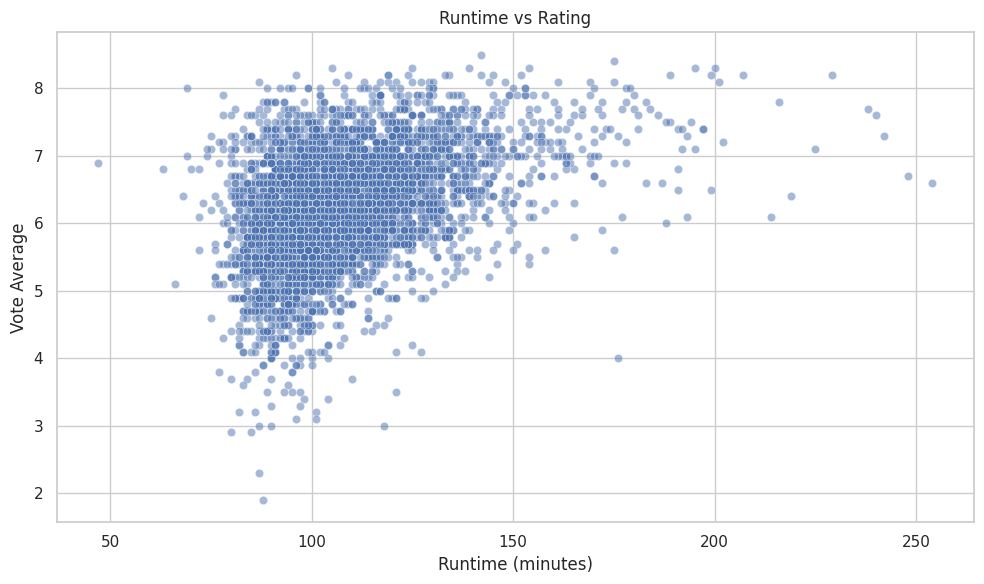

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=movies, x='runtime', y='vote_average', alpha=0.5)

plt.title("Runtime vs Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig02_scatter_runtime_rating.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter plot suggests a slight positive relationship between runtime and audience ratings. While the trend is not very strong, longer movies tend to receive slightly higher ratings.



### Correlation

In [38]:
corr = movies[['runtime', 'vote_average']].corr()
print(corr)

               runtime  vote_average
runtime       1.000000      0.401998
vote_average  0.401998      1.000000


### Runtime Bucket



In [39]:
movies['runtime_bucket'] = pd.cut(
    movies['runtime'],
    bins=[0, 80, 100, 120, 140, 160, 300],
    labels=['40-80', '81-100', '101-120', '121-140', '141-160', '160+']
)

bucket_means = movies.groupby('runtime_bucket')['vote_average'].mean()
print(bucket_means)

runtime_bucket
40-80      6.043750
81-100     5.906274
101-120    6.316742
121-140    6.681222
141-160    6.974556
160+       7.237000
Name: vote_average, dtype: float64


###Bar Chart

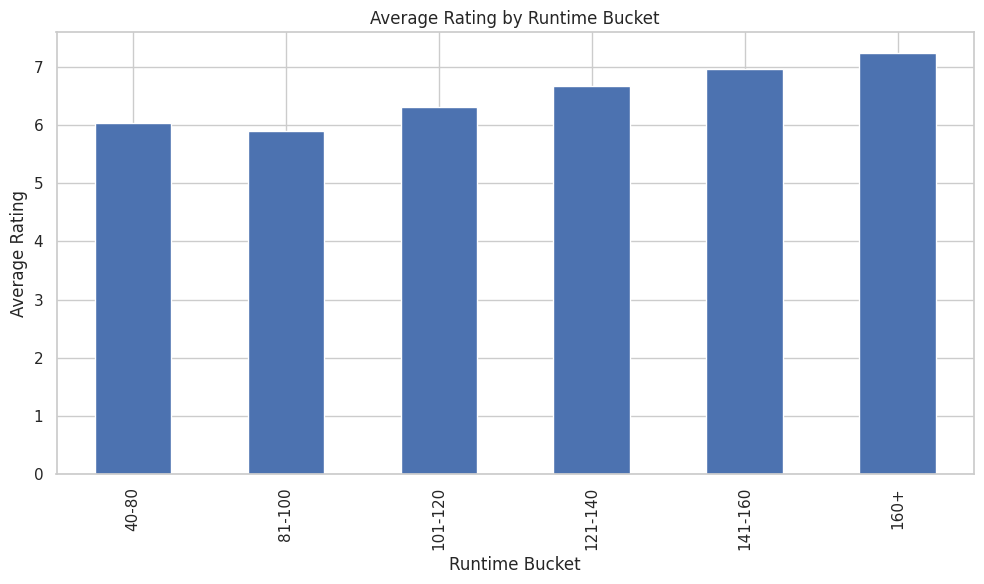

In [40]:
plt.figure(figsize=(10,6))
bucket_means.plot(kind='bar')

plt.title("Average Rating by Runtime Bucket")
plt.xlabel("Runtime Bucket")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.savefig("fig03_bar_bucket_ratings.png", dpi=300, bbox_inches="tight")
plt.show()

The bar chart shows that average ratings increase as runtime increases. Movies longer than 100 minutes tend to have higher average ratings compared to shorter films.

###Boxplot

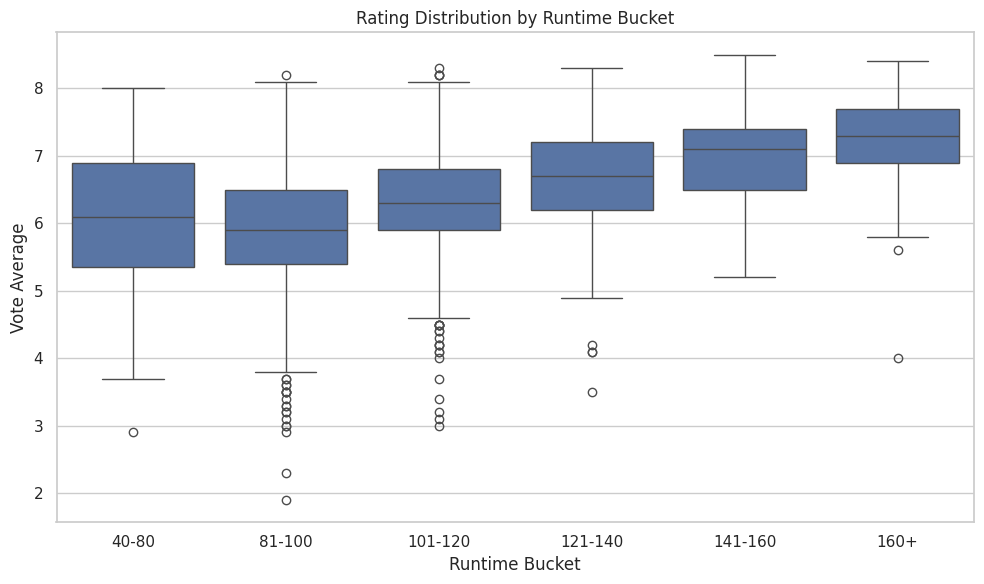

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=movies, x='runtime_bucket', y='vote_average')

plt.title("Rating Distribution by Runtime Bucket")
plt.xlabel("Runtime Bucket")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig04_boxplot_buckets.png", dpi=300, bbox_inches="tight")
plt.show()

The boxplot indicates that longer movies generally have higher median ratings and more consistent rating distributions compared to shorter movies.

## Hypothesis Testing
A one-way ANOVA test is used to determine whether ratings differ significantly across runtime groups.

### ANOVA

In [42]:
groups = [group['vote_average'].values for name, group in movies.groupby('runtime_bucket')]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA F-statistic: 162.54843584610649
p-value: 3.724078771227376e-158


The ANOVA test evaluates whether the average ratings differ across runtime groups.

If the p-value is less than 0.05, it indicates that at least one runtime group has a significantly different mean rating, meaning runtime has a statistically significant effect on ratings.

## Regression Analysis
Linear and polynomial regression models are used to examine the relationship between runtime and ratings.

###  Simple Linear Regression


In [43]:
X = movies[['runtime']]
y = movies['vote_average']

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_[0])
print("R^2:", r2)
print(f"Model: vote_average = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} * runtime")

Intercept: 4.40338780103226
Slope: 0.017066681400886817
R^2: 0.1616022362148668
Model: vote_average = 4.4034 + 0.0171 * runtime


###  Linear Regression — Controlling for Confounders

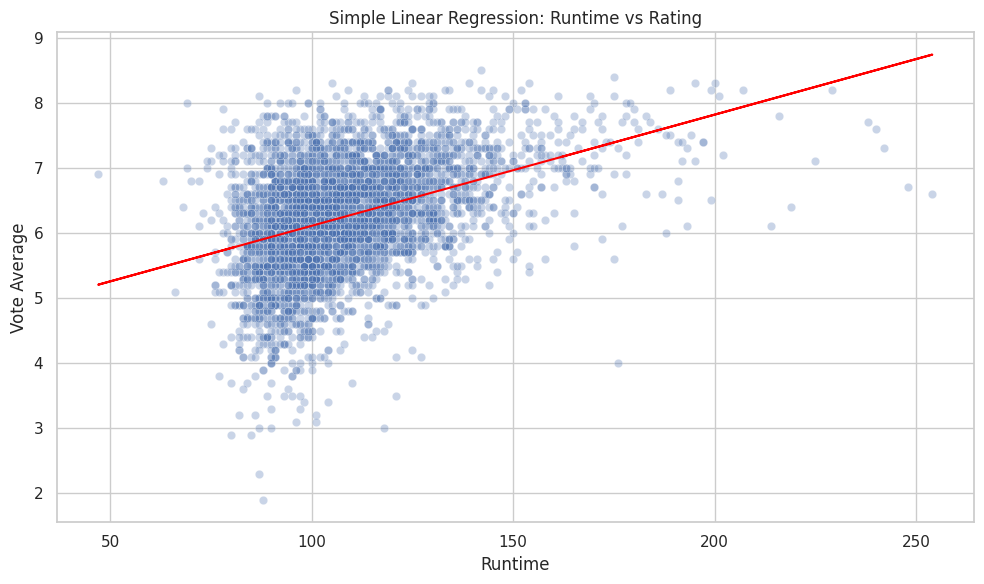

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=movies, x='runtime', y='vote_average', alpha=0.3)
plt.plot(movies['runtime'], y_pred, color='red')

plt.title("Simple Linear Regression: Runtime vs Rating")
plt.xlabel("Runtime")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig05_linear_regression.png", dpi=300, bbox_inches="tight")
plt.show()

###Polynomial Regression

In [45]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

x_range = np.linspace(40, 300, 1000).reshape(-1,1)
y_pred_range = poly_model.predict(poly.transform(x_range))

optimal_runtime = x_range[np.argmax(y_pred_range)][0]

print("Optimal runtime:", optimal_runtime)

Optimal runtime: 227.12712712712715


###Polynomial Regresion Graphic

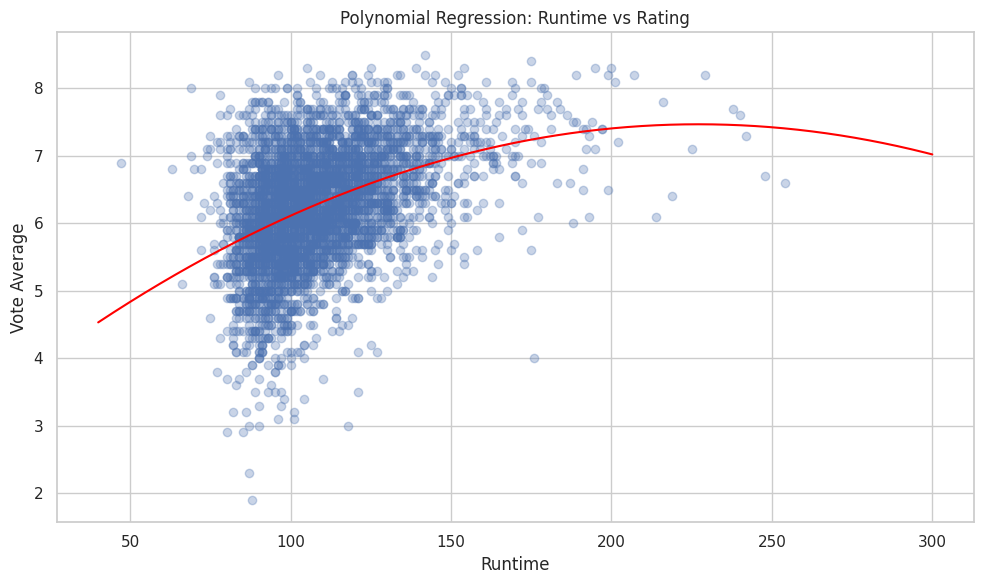

In [46]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha=0.3)
plt.plot(x_range, y_pred_range, color='red')

plt.title("Polynomial Regression: Runtime vs Rating")
plt.xlabel("Runtime")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig06_poly_regression.png", dpi=300, bbox_inches="tight")
plt.show()

The linear regression model shows a positive relationship between runtime and ratings, although the R² value suggests that runtime alone explains only a small portion of the variation.

The polynomial regression captures non-linear patterns and suggests that ratings increase up to a certain runtime range before stabilizing.

##Conclusion

This analysis examined whether movie runtime has a significant effect on audience ratings.

The correlation analysis showed a moderate positive relationship (r ≈ 0.37), suggesting that longer movies tend to receive higher ratings.

The ANOVA test indicated that ratings differ significantly across runtime groups (p < 0.05), meaning runtime has a statistically significant effect on ratings.

Regression analysis further supported this finding, showing a positive relationship between runtime and rating. The polynomial regression suggested an optimal runtime range around 120–160 minutes, where ratings tend to be highest.

Therefore, we reject the null hypothesis (H0) and conclude that movie runtime has a significant impact on audience ratings.

However, extremely long movies may not always guarantee higher ratings, indicating diminishing returns beyond a certain point.

##Limitations

This analysis is limited by the dataset and does not include other influential factors such as genre, budget, or director. Future work could incorporate these variables for a more comprehensive analysis.

---
*End of Analysis — DSA 210 Spring 2026 Term Project*